### Initialise and import stuff


In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2]:
def f(x):
    return 3 * x**2 - 4 * x + 5

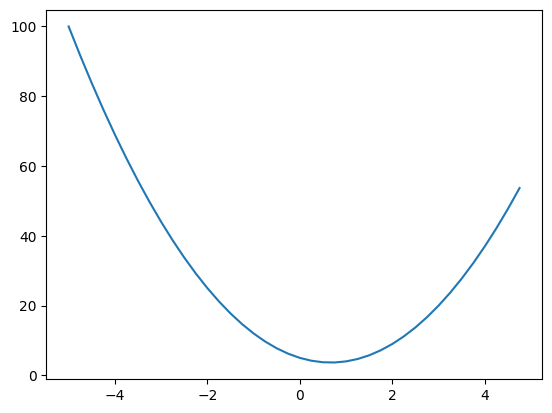

In [3]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [4]:
# numerical derivative
h = 0.00000000001
a = -3.0
(f(a + h) - f(a))/h

-21.999824184604222

### Formally defining a `Value` class

- **`data`**: data of the node  
- **`grad`**: d(root)/d(self)  
- **`_prev`**: children of node (technically parents)  
- **`_op`**: operation between children (parents) which lead to node  
- **`_back`**: propagates self.grad to parents based on `_op`  
- **`back`**: does backward propagation with self as root  


In [37]:
import math

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # derivative of graph root (final output), wrt self
        self._back = lambda: None # func which propagates grad to parents
        self._prev = set(_children)
        self._op = _op
        self.label = label 

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f}, label={self.label})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        # when node = result of add, the grad of the terms leading to it:
        # out calls _back = updates grad of parents
        def back(): # dout/dself and dout/dother
            self.grad += 1.00 * out.grad
            other.grad += 1.00 * out.grad
        out._back = back

        return out
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return other + (-self)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def back():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._back = back

        return out
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __pow__(self, other): # self ** other
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,), f'**{other}')

        def back(): # dout/dself
            self.grad += other * (self.data**(other-1)) * out.grad
        out._back = back

        return out
    
    def __truediv__(self, other): # self / other
        return self * (other**-1)
    
    def __rtruediv__(self, other): # other / self
        return other * (self**-1)
    
    def exp(self):
        val = math.exp(self.data)
        out = Value(val, (self, ), 'exp')

        def back():
            self.grad += val * out.grad
        out._back = back

        return out
    
    def tanh(self):
        # e = (self*2).exp()
        # return (e - 1) / (e + 1)
        val = math.exp(2*self.data)
        out = Value((val-1)/(val+1), (self, ), 'tanh')

        def back():
            self.grad += (1-out.data**2) * out.grad
        out._back = back

        return out
    
    def relu(self):
        val = self.data if self.data > 0 else 0
        out = Value(val, (self,), 'relu')

        def back():
            self.grad += (val > 0) * out.grad
        out._back = back

        return out
    
    # public backward propagation function
    def back(self, reset=True):
        topo = []
        topo: list[Value]
        vis = set()
        def dfs(u: Value):
            vis.add(u)
            if reset:
                u.grad = 0
            for v in u._prev:
                if v not in vis:
                    dfs(v)
            topo.append(u)
        dfs(self)
        
        self.grad = 1
        for u in reversed(topo):
            u._back()

In [4]:
a = Value(3.0, label='a')
b = Value(2, label='b')
a = 3 - b
a

Value(data=1.0000, grad=0.0000, label=)

### Graph visualisation

- create a trace = dfs through some root node
- this gives us the `nodes` and `edges` of the subgraph at rooted at root
- when drawing a graph:
    - first add all nodes
    - if result of some `op`, add that as node, with edge from `op` to `self`
    - add edges between `prev` and `self.op`

In [5]:
# in order to visualise, import from some graph visualisation software
from graphviz import Digraph

def trace(root: Value):
    nodes, edges = set(), set()
    nodes: set[Value]
    edges: set[tuple[Value, Value]]

    def dfs(u: Value):
        nodes.add(u)
        for v in u._prev:
            edges.add((v, u))
            if v not in nodes:
                dfs(v)
    
    dfs(root)
    return nodes, edges

def draw_graph(root: Value):
    # digraph, of svg type, going from left to right
    graph = Digraph(format='png', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    for u in nodes:
        uid = str(id(u))
        ulab = f"{{ {u.label} | data={u.data: .4f} | grad={u.grad: .4f} }}"
        # add u as a node to the graph, with name and label, with rectangle shape
        graph.node(name=uid, label=ulab, shape='record')

        # if u is a result of some op, add node of op, edge from op to u
        if u._op != '':
            graph.node(name=uid + u._op, label=u._op)
            graph.edge(tail_name=uid + u._op, head_name=uid)
    
    for v, u in edges:
        # add edge from parent to child's op
        uid = str(id(u))
        vid = str(id(v))
        graph.edge(vid, uid + u._op)

    return graph

### Example 1

In [8]:
x1 = Value(3.00, label='x1')
x2 = Value(-2.0, label='x2')
w1 = Value(2.29, label='w1')
w2 = Value(-3.145, label='w2')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x = x1w1 + x2w2; x.label = 'x'
b = Value(-12.331, label='b')
n = x + b; n.label = 'n'
a = n.tanh()

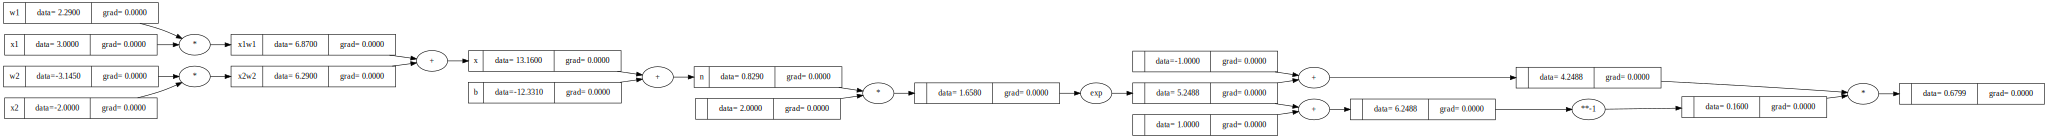

In [9]:
g = draw_graph(a)
g

### Auto Backpropagation after topo sort
- since the graph is a DAG, efficient way to go about updating the `grad` is after linearizing it
- do a single DFS run, get the topo (reverse topo) sort order, and process `_back` in that order

Value(data=-1.0000, grad=0.0000, label=)
Value(data=2.0000, grad=0.0000, label=)
Value(data=-12.3310, grad=0.0000, label=b)
Value(data=-2.0000, grad=0.0000, label=x2)
Value(data=-3.1450, grad=0.0000, label=w2)
Value(data=6.2900, grad=0.0000, label=x2w2)
Value(data=2.2900, grad=0.0000, label=w1)
Value(data=3.0000, grad=0.0000, label=x1)
Value(data=6.8700, grad=0.0000, label=x1w1)
Value(data=13.1600, grad=0.0000, label=x)
Value(data=0.8290, grad=0.0000, label=n)
Value(data=1.6580, grad=0.0000, label=)
Value(data=5.2488, grad=0.0000, label=)
Value(data=4.2488, grad=0.0000, label=)
Value(data=1.0000, grad=0.0000, label=)
Value(data=6.2488, grad=0.0000, label=)
Value(data=0.1600, grad=0.0000, label=)
Value(data=0.6799, grad=0.0000, label=)


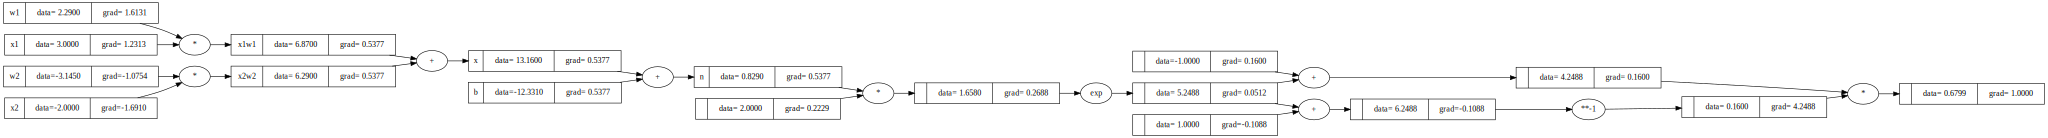

In [10]:
# to do the above automatically, topo sort nodes and process in that order
topo = []
topo: list[Value]
vis = set()
def dfs(u: Value):
    vis.add(u)
    for v in u._prev:
        if v not in vis:
            dfs(v)
    topo.append(u)

dfs(a)
for u in topo:
    print(u)

# now procress back passes in reverse topo order
a.grad = 1
for u in reversed(topo):
    u._back()

draw_graph(a)

### Auto BackProp as part of `Value` class 

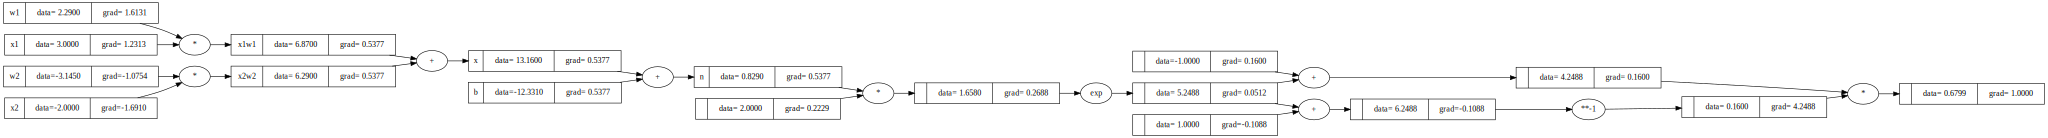

In [11]:
# the above is put into Value class's back function, so we can back prop from any node
a.back()
draw_graph(a)

### Example 2
- before this example, gradients of each node were simply equated
    - `grad = expression`
- this worked only in the case of a tree-type graph, where each node was affected by only 1 node
- in order to make it work for multiple edges, i.e, a node was a child (parent) to multiple nodes:
    - `grad += expression`

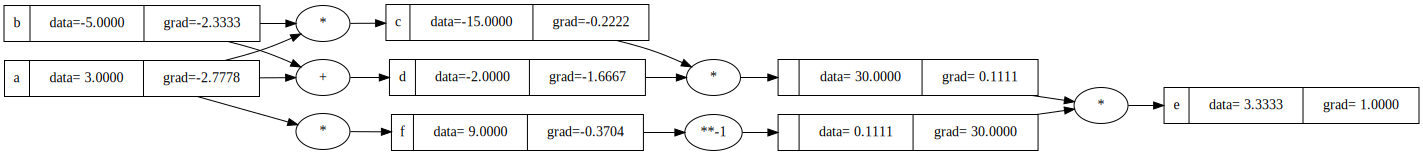

In [ ]:
a = Value(3, label='a')
b = Value(-5, label='b')
c = a*b; c.label = 'c'
d = a+b; d.label = 'd'
f = a*a; f.label = 'f'
e = c*d / f; e.label = 'e'

e.back()
draw_graph(e)

### Neuron and MLP


In [32]:
import random
from value import Value

class Neuron:
    def __init__(self, nin, act='tanh'):
        self.actfun = act
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
    
    # use object as function through call: neu(x) 
    def __call__(self, x):
        act = self.b
        for wi, xi in zip(self.w, x):
            act = act + wi*xi
        out = eval(f"act.{self.actfun}()")
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
    def __repr__(self):
        return f"Neuron({len(self.w)})"

class Layer:
    def __init__(self, nin, nout, act='tanh'):
        self.neurons = [Neuron(nin, act) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    
    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        
        return params
    
    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"
    
class MLP:
    def __init__(self, nin, nouts, act='tanh'):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], act) for i in range(len(nouts))]

    def __call__(self, x):
        outs = x
        for layer in self.layers:
            outs = layer(outs)
        return outs
    
    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        
        return params
    
    def __repr__(self):
        return f"MLP of [\n{'\n'.join(str(l) for l in self.layers)}\n]"

### Final regression exmaple

In [62]:
# initialise the mlp
lays = [4, 4, 1]
mlp = MLP(3, lays, 'relu') # the multi layered perceptron
len(mlp.parameters())
mlp

MLP of [
Layer of [Neuron(3), Neuron(3), Neuron(3), Neuron(3)]
Layer of [Neuron(4), Neuron(4), Neuron(4), Neuron(4)]
Layer of [Neuron(4)]
]

In [61]:
# initial data set
xs = [
    [3, 2],
    [4, 1],
    [1, 2.4],
    [2, 2]
]
ys = [0, 1, 2, 1.1]

In [51]:
# calculating the loss initially
yout = [mlp(row) for row in xs]
loss = sum([(true-pred)**2 for true, pred in zip(ys, yout)])
loss.label = 'loss'
loss

Value(data=10.3047, grad=0.0000, label=loss)

In [13]:
# back propagate, get the gradient and data of some param
loss.back()
print(mlp.layers[0].neurons[0].w[0].data, mlp.layers[0].neurons[0].w[0].grad)

-0.8823143983685879 -4.223397732056094


In [65]:
# iterate param update until loss is below some threshold
for epochs in range(1000):
    # forward pass
    yout = [mlp(row) for row in xs]
    loss = sum([(true-pred)**2 for true, pred in zip(ys, yout)])
    
    # backward pass
    loss.back()

    # udpate each param through gradient descent
    for p in mlp.parameters():
        p.data -= p.grad * 0.01

loss

Value(data=0.0000, grad=1.0000, label=)

In [66]:
for x in xs:
    print(mlp(x).data)

0.0014075783766202
1.0002464035316172
2.0023024887897183
1.1004974531714908
